# Multilevel Graph with focus on NLP for now.

In [1]:
from typing import Any

import nltk
import glob
import random


In [2]:
pos_imdb = glob.glob("../data/datasets/IMDB/test/raw/positive/*.txt")
neg_imdb = glob.glob("../data/datasets/IMDB/test/raw/negative/*.txt")

imdb_test = pos_imdb + neg_imdb

random.shuffle(imdb_test)

selected_file = imdb_test[0]
print(f"Selected file: {selected_file}")
doc = open(selected_file).read()

print("-" * 50)
print(doc)
print("-" * 50)

Selected file: ../data/datasets/IMDB/test/raw/positive/47755.txt
--------------------------------------------------
Lost holds something interesting for everyone. You can say an awfully lot about this series, and an awfully lot has been said, so I won't be the one to spell it all out for you again. Just read the persons who loved it, and you'll know why you want to watch it. The nice thing about this series is that its totally new. There are not much movies -and even fewer- series based on the theme of only suspense, but Lost lives up to the theme with pride. Its all about the unexplained and if you combine that with an exotic location, nice plot twists, an excellent cast and a good format (present and past combined in single episodes) you'll have a series in which every episode is a story on its own but part of a greater telling. You want to have all the insights of the characters, you want to see the overall picture and you'll want to know where the writers are taking you. The result

In [3]:
doc = doc.replace("<br />", "\n")
print(doc)

Lost holds something interesting for everyone. You can say an awfully lot about this series, and an awfully lot has been said, so I won't be the one to spell it all out for you again. Just read the persons who loved it, and you'll know why you want to watch it. The nice thing about this series is that its totally new. There are not much movies -and even fewer- series based on the theme of only suspense, but Lost lives up to the theme with pride. Its all about the unexplained and if you combine that with an exotic location, nice plot twists, an excellent cast and a good format (present and past combined in single episodes) you'll have a series in which every episode is a story on its own but part of a greater telling. You want to have all the insights of the characters, you want to see the overall picture and you'll want to know where the writers are taking you. The result of that is that its a series which does not let you go. On a more sceptic note, the series went under a bit in seas

In [6]:
sentences = nltk.sent_tokenize(doc)
[print(sentence.strip(), "\n--") for sentence in sentences]

Lost holds something interesting for everyone. 
--
You can say an awfully lot about this series, and an awfully lot has been said, so I won't be the one to spell it all out for you again. 
--
Just read the persons who loved it, and you'll know why you want to watch it. 
--
The nice thing about this series is that its totally new. 
--
There are not much movies -and even fewer- series based on the theme of only suspense, but Lost lives up to the theme with pride. 
--
Its all about the unexplained and if you combine that with an exotic location, nice plot twists, an excellent cast and a good format (present and past combined in single episodes) you'll have a series in which every episode is a story on its own but part of a greater telling. 
--
You want to have all the insights of the characters, you want to see the overall picture and you'll want to know where the writers are taking you. 
--
The result of that is that its a series which does not let you go. 
--
On a more sceptic note, the

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [7]:
tokens_0 = nltk.word_tokenize(sentences[0].lower().strip())
print(tokens_0)

['lost', 'holds', 'something', 'interesting', 'for', 'everyone', '.']


## Char N-Grams

In [8]:
import os
from collections import Counter


def get_char_ngrams(text, n):
    return [text[i:i + n] for i in range(len(text) - n + 1)]


def clean_text(text):
    return text.lower().replace("<br />", "\n").replace("\ufeff", "")


def process_corpus(directory, n):
    ngram_counter = Counter()

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            with open(os.path.join(directory, filename), "r", encoding="utf-8") as f:
                text = clean_text(f.read())  # normalize to lowercase
                ngrams = get_char_ngrams(text, n)
                ngram_counter.update(ngrams)

    return ngram_counter


# Usage
# directory_path = "../data/datasets/Imprisonment-IT/train/raw/NotReleased"
directory_path = "../data/datasets/IMDB/train/raw/positive"
n = 1  # for trigrams
top_ngrams = process_corpus(directory_path, n).most_common(20000)

# Display results
for ngram, count in top_ngrams:
    print(f"{ngram!r}: {count}")


' ': 4552936
'e': 2478186
't': 1913462
'a': 1683913
'i': 1598562
'o': 1518972
's': 1412966
'n': 1376644
'r': 1180558
'h': 1118604
'l': 922041
'd': 720991
'c': 585751
'm': 574724
'u': 541481
'f': 472129
'g': 426790
'y': 426668
'w': 400559
'p': 349637
'b': 321003
'v': 259758
'.': 252535
',': 226061
'k': 172302
"'": 100391
'\n': 77620
'-': 51511
'"': 50482
'j': 47645
'x': 35403
')': 29255
'(': 28797
'z': 19247
'!': 18690
'q': 16832
'0': 14985
'1': 14948
'9': 8744
'?': 7707
':': 7493
'2': 5862
';': 5767
'/': 5459
'*': 4420
'5': 4158
'8': 3934
'7': 3792
'3': 3771
'4': 3163
'6': 2678
'&': 2618
'é': 1141
'\x96': 1094
'\x85': 598
'`': 589
'_': 572
'$': 413
'=': 347
'%': 294
'+': 278
'\x97': 274
'#': 254
'´': 193
'á': 135
'}': 120
'{': 117
']': 115
'ö': 112
'[': 108
'>': 94
'è': 93
'\x91': 83
'’': 79
'~': 75
'@': 72
'ó': 62
'\t': 60
'ä': 56
'¨': 54
'ü': 50
'^': 49
'í': 48
'ñ': 43
'à': 41
'£': 40
'–': 37
'¡': 37
'ô': 36
'ï': 31
'ç': 30
'<': 30
'ã': 28
'\xa0': 26
'“': 25
'»': 25
'”': 24
'«': 23
'

# Preprocessing

In [9]:
import glob
import random
import tqdm
import nltk
import unicodedata
import re
import contractions
import nltk
import spacy
import glob

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Load SpaCy English model
nlp = spacy.load('en_core_web_lg')


In [10]:

pos_imdb = glob.glob("../data/datasets/IMDB/train/raw/positive/*.txt")
neg_imdb = glob.glob("../data/datasets/IMDB/train/raw/negative/*.txt")

imdb_test = pos_imdb + neg_imdb

random.shuffle(imdb_test)

In [11]:
positive_raw_dataset = [open(f).read() for f in pos_imdb]
negative_raw_dataset = [open(f).read() for f in neg_imdb]


In [12]:
import unicodedata
import re
import contractions
import nltk
import spacy
from nltk.tokenize import sent_tokenize

# Ensure necessary NLTK data is downloaded
nltk.download('punkt', quiet=True)

# Load spaCy English model
nlp = spacy.load('en_core_web_lg')


def preprocessing_imdb(text: str):
    def _replace_chars_and_symbols(target):
        # Mapping less frequent symbols to words or removing them
        replace_chars_with_words = {
            # "&": " and ",
            # "%": " percent ",
            "--": " - ",
            "²": " squared ",
            "®": " registered ",
            "•": " bullet ",
            "<": " less than ",
            ">": " greater than ",
            "¬": " not ",
            "�": "",
            "™": " trademark ",
            "°": " degrees ",
            "½": " half ",
            "¼": " quarter ",
            "¾": " three quarters ",
            "–": "-", "—": "-",
            "‘": "'", "’": "'", "“": '"', "”": '"', "´": "'", "`": "'", "¨": '"',
            "…": "...", "×": " x ", "÷": " divided by ", "±": " plus-minus ",
            "§": " section ", "¶": " paragraph ", "€": " euro ", "£": " pound ",
            "¥": " yen ", "$": " dollar ", "¢": " cent ", "#": " number ", "@": " at ",
            "^": "", "~": "", "|": "", "\\": "",
            "\"": "",
            "\t": " ", "\n": "\n", "\r": " ",
        }

        # Replace specific HTML tags and BOM
        target = target.replace("<br />", "\n").replace("\ufeff", "")

        # Remove or replace specific HTML/XML-like tags
        html_tags = ['<em>', '</em>', '<p>', '</p>', '<spoiler>', '</spoiler>']
        for tag in html_tags:
            target = target.replace(tag, '')

        # Replace '<3' with 'love'
        target = target.replace('<3', ' love ')

        # Remove sequences like '<<<<<', '>>>>>>>>>', '<sp?'
        target = re.sub(r'<{2,}', '', target)
        target = re.sub(r'>{2,}', '', target)
        target = re.sub(r'<sp\?', '', target)

        # Apply replacements
        for char, replacement in replace_chars_with_words.items():
            target = target.replace(char, replacement)

        return target

    def _normalize_unicode(text):
        # Normalize unicode characters to ASCII
        text = unicodedata.normalize('NFKD', text)
        text = text.encode('ascii', 'ignore').decode('utf-8', 'ignore')
        return text

    def _expand_contractions(text):
        # Expand contractions using the contractions library
        return contractions.fix(text)

    def _extract_possessive_relations(doc):
        relations = []
        for token in doc:
            if token.dep_ == 'poss':
                possessor = token.text
                possessed = token.head.text
                relations.append((possessor, 'possesses', possessed))
        return relations

    # Step 1: Replace less frequent characters and symbols
    pre_processed = _replace_chars_and_symbols(text)

    # Step 2: Normalize unicode characters
    pre_processed = _normalize_unicode(pre_processed)

    # Step 3: Expand contractions
    pre_processed = _expand_contractions(pre_processed)

    # Step 4: Tokenize into sentences
    splitted_sentences = sent_tokenize(pre_processed)

    # Step 5: Process each sentence with spaCy and extract possessive relations
    processed_sentences = []

    for sentence in splitted_sentences:

        doc = nlp(sentence)
        # Extract possessive relations
        # possessive_relations = _extract_possessive_relations(doc)
        # Selective lowercasing: preserve 'I' and proper nouns
        words = []
        special_case = False
        for i, token in enumerate(doc):
            if token.text == "'s" and i > 0:
                # Handle possessive 's
                words[-1] = words[-1] + "'s"
            elif token.text == "'":

                head = token.head
                if head.dep_ == "poss":
                    # e.g., Glovers'
                    if len(words) > 0:
                        words[-1] = words[-1] + "'"
                elif re.match(r"\d{2}s", head.text):
                    # e.g., '70s ➝ '70s
                    words.append("'" + head.text)
                elif head.text.startswith("'") or (i + 1 < len(doc) and doc[i + 1].text.endswith("s")):
                    continue
                    # stylized or partial decade, skip extra quote
                else:
                    continue  # skip standalone apostrophes
                    # Most likely just a quote
                    # print(f"Else case: Token={token.text}, Head={head.text}, Dep={token.dep_}, Pos={token.pos_}" )

            elif token.text == "I" or token.pos_ == "PROPN":
                words.append(token.text)
            else:
                words.append(token.text.lower())

        if special_case:
            print("Sentence:", sentence)
            print("words:", words)
        processed_sentence = ' '.join(words)

        recover_chars = {
            " , ": ", ",
            " .": ". ",
            " ; ": "; ",
            " ; ": "; ",
            " ; ": "; ",
            " \" ": " ",
            " ! ": "! ",
            "( ": " (",
            " )": ") ",
            " - ": "-",
            " !": "! ",
            " ?": "? ",
            " :": ": ",
            "  ": " "
        }

        for i in range(3):
            for char in recover_chars.keys():
                processed_sentence = processed_sentence.replace(char, recover_chars[char])

        processed_sentence = re.sub(r'(\w)([\(\{\[])', r'\1 \2', processed_sentence)
        processed_sentence = re.sub(r'([\)\}\]])(\w)', r'\1 \2', processed_sentence)

        processed_sentences.append(processed_sentence.strip())

    return processed_sentences, splitted_sentences


In [13]:
import random
import nltk
from collections import Counter
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch

nltk.download('punkt', quiet=True)


def tokenize(text):
    return nltk.word_tokenize(text.lower())


def vocab_size(texts):
    all_tokens = []
    for text in texts:
        all_tokens.extend(tokenize(text))
    return len(set(all_tokens))


def token_overlap(original_texts, processed_texts):
    overlaps = []
    for orig, proc in zip(original_texts, processed_texts):
        orig_tokens = set(tokenize(orig))
        proc_tokens = set(tokenize(proc))
        if len(orig_tokens) == 0:
            overlaps.append(0.0)
            continue
        overlap = len(orig_tokens.intersection(proc_tokens)) / len(orig_tokens)
        overlaps.append(overlap)
    return sum(overlaps) / len(overlaps) if len(overlaps) > 0 else 0.0


def calculate_perplexity(texts, model, tokenizer, device='cpu'):
    model.eval()
    total_loss = 0.0
    total_length = 0
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors='pt').to(device)
            outputs = model(**inputs, labels=inputs['input_ids'])
            loss = outputs.loss
            length = inputs['input_ids'].size(1)
            total_loss += loss.item() * length
            total_length += length
    perplexity = torch.exp(torch.tensor(total_loss / total_length)).item()
    return perplexity


def sample_inspection(original_texts, processed_texts, n=5):
    indices = random.sample(range(len(original_texts)), n)
    for idx in indices:
        print(f"--- Example {idx} ---")
        print("Original:  ", original_texts[idx])
        print("Processed: ", processed_texts[idx])
        print()



In [14]:
# Your preprocessing loop with metrics integration
preprocessed_dataset = []
processed_sentences_flat = []
original_sentences_flat = []

positive_processed_dataset = []
negative_processed_dataset = []

random.shuffle(positive_raw_dataset)
random.shuffle(negative_raw_dataset)

for doc_text in tqdm.tqdm(positive_raw_dataset[:2000], desc="Preprocessing Positive IMDB"):
    preprocessed_doc, original_doc = preprocessing_imdb(doc_text)  # This returns list of sentences
    processed_sentences_flat.extend(preprocessed_doc)
    original_sentences_flat.extend(original_doc)

    positive_processed_dataset.append(preprocessed_doc)

for doc_text in tqdm.tqdm(negative_raw_dataset[:2000], desc="Preprocessing Negative IMDB"):
    preprocessed_doc, original_doc = preprocessing_imdb(doc_text)  # This returns list of sentences
    processed_sentences_flat.extend(preprocessed_doc)
    original_sentences_flat.extend(original_doc)

    negative_processed_dataset.append(preprocessed_doc)


Preprocessing Negative IMDB: 100%|██████████| 2000/2000 [02:24<00:00, 13.83it/s]


In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
# model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

In [19]:
print(f"Vocabulary size (original): {vocab_size(original_sentences_flat)}")
print(f"Vocabulary size (processed): {vocab_size(processed_sentences_flat)}")

avg_overlap = token_overlap(original_sentences_flat, processed_sentences_flat)
print(f"Average token overlap (processed vs original): {avg_overlap:.3f}")

# print("Loading GPT2 model for perplexity estimation... (may take a while)")
#
# ppl = calculate_perplexity(processed_sentences_flat, model, tokenizer, device=device)
# print(f"Perplexity on processed text (GPT-2): {ppl:.2f}")

print("\nRandom sample inspection:")
sample_inspection(original_sentences_flat, processed_sentences_flat, n=5)


Vocabulary size (original): 40672
Vocabulary size (processed): 40989
Average token overlap (processed vs original): 0.992

Random sample inspection:
--- Example 37207 ---
Original:   Incidentally, I may be just too old, but having lived on Tyneside for 42 years, I have never heard anyone outside this film use the expression Purely Belter.
Processed:  incidentally, I may be just too old, but having lived on Tyneside for 42 years, I have never heard anyone outside this film use the expression purely Belter.

--- Example 8562 ---
Original:   I think Warner Brothers Studios should release a DVD that contains all 13 episodes.
Processed:  I think Warner Brothers Studios should release a dvd that contains all 13 episodes.

--- Example 42916 ---
Original:   At times I felt reminded of the student film competition at the beginning of Christopher Guest's The Big Picture.
Processed:  at times I felt reminded of the student film competition at the beginning of Christopher Guest's the Big Picture.


# Text to Graph

In [20]:
nlp = spacy.load('en_core_web_lg')

In [21]:
def process_doc_from_sentences(sentences):
    # sentences: list of str
    all_tokens = []
    sentence_token_indices = []  # to track which tokens belong to which sentence

    for sent in sentences:
        doc = nlp(sent)
        tokens = [token for token in doc if not token.is_space]
        start_idx = len(all_tokens)
        all_tokens.extend(tokens)
        sentence_token_indices.append((start_idx, len(all_tokens)))

    return all_tokens, sentence_token_indices


In [22]:
import torch
from torch_geometric.data import HeteroData
from sklearn.metrics.pairwise import cosine_similarity

list_sims = []


def build_hetero_graph_from_tokens(sentences):
    all_tokens, sentence_token_indices = process_doc_from_sentences(sentences)

    hetero_data = HeteroData()

    # Save tokens as strings
    all_tokens_text = [token.text for token in all_tokens]
    hetero_data['word'].tokens = all_tokens_text

    # Word nodes + embeddings
    word_embeddings = torch.tensor([token.vector for token in all_tokens], dtype=torch.float)
    hetero_data['word'].x = word_embeddings

    # Sentence nodes: average word embeddings per sentence
    sentence_embeddings = []
    for start, end in sentence_token_indices:
        if end > start:
            sent_emb = torch.mean(word_embeddings[start:end], dim=0)
        else:
            sent_emb = torch.zeros(word_embeddings.size(1))  # fallback for empty sentence
        sentence_embeddings.append(sent_emb)
    sentence_embeddings = torch.stack(sentence_embeddings)
    hetero_data['sentence'].x = sentence_embeddings

    # Document node: average sentence embeddings
    doc_embedding = torch.mean(sentence_embeddings, dim=0, keepdim=True)
    hetero_data['document'].x = doc_embedding

    # ==== Edges ====

    # Word sequence edges (within each sentence)
    word_seq_edges = []
    for start, end in sentence_token_indices:
        for i in range(start, end - 1):
            word_seq_edges.append([i, i + 1])
    if word_seq_edges:
        word_seq_edges = torch.tensor(word_seq_edges).t().contiguous()
    else:
        word_seq_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'seq', 'word'].edge_index = word_seq_edges

    # Dependency edges (token.head must be in all_tokens)
    token_to_idx = {token.i: idx for idx, token in enumerate(all_tokens)}
    word_dep_edges = []
    for idx, token in enumerate(all_tokens):
        head = token.head
        if head.i in token_to_idx and head.i != token.i:
            head_idx = token_to_idx[head.i]
            word_dep_edges.append([head_idx, idx])
    if word_dep_edges:
        word_dep_edges = torch.tensor(word_dep_edges).t().contiguous()
    else:
        word_dep_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'dep', 'word'].edge_index = word_dep_edges

    # Sentence sequence edges
    sent_seq_edges = [[i, i + 1] for i in range(len(sentences) - 1)]
    if sent_seq_edges:
        sent_seq_edges = torch.tensor(sent_seq_edges).t().contiguous()
    else:
        sent_seq_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['sentence', 'seq', 'sentence'].edge_index = sent_seq_edges

    # Sentence semantic similarity edges
    sims = cosine_similarity(sentence_embeddings)
    sent_sim_edges = []
    for i in range(len(sentences)):
        for j in range(i + 1, len(sentences)):
            list_sims.append(sims[i, j])
            if sims[i, j] > 0.9:
                sent_sim_edges.append([i, j])
                sent_sim_edges.append([j, i])
    if sent_sim_edges:
        sent_sim_edges = torch.tensor(sent_sim_edges).t().contiguous()
    else:
        sent_sim_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['sentence', 'sim', 'sentence'].edge_index = sent_sim_edges

    # Words -> Sentences (belongs)
    word_to_sent_edges = []
    for sent_idx, (start, end) in enumerate(sentence_token_indices):
        for word_idx in range(start, end):
            word_to_sent_edges.append([word_idx, sent_idx])
    if word_to_sent_edges:
        word_to_sent_edges = torch.tensor(word_to_sent_edges).t().contiguous()
    else:
        word_to_sent_edges = torch.empty((2, 0), dtype=torch.long)
    hetero_data['word', 'belongs', 'sentence'].edge_index = word_to_sent_edges

    # Sentences -> Document (belongs)
    sent_to_doc_edges = torch.tensor([[i for i in range(len(sentences))], [0] * len(sentences)], dtype=torch.long)
    hetero_data['sentence', 'belongs', 'document'].edge_index = sent_to_doc_edges

    return hetero_data


In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import torch_geometric.utils as pyg_utils


def plot_hetero_graph(hetero_data, filename=None):
    plt.clf()
    plt.figure(figsize=(30, 16))

    # Add node_type and node_idx attrs for conversion
    for ntype in hetero_data.node_types:
        hetero_data[ntype].node_type = [ntype] * hetero_data[ntype].num_nodes
        hetero_data[ntype].node_idx = list(range(hetero_data[ntype].num_nodes))

    G = pyg_utils.to_networkx(hetero_data, node_attrs=['node_type', 'node_idx'], to_multi=True)

    print("Edge types in hetero_data:", hetero_data.edge_types)
    for etype in hetero_data.edge_types:
        count = hetero_data[etype].edge_index.size(1)
        print(f"Edge type {etype}: {count} edges")

    node_type_colors = {
        'word': 'skyblue',
        'sentence': 'lightgreen',
        'document': 'orange'
    }

    edge_type_colors = {
        ('word', 'seq', 'word'): 'blue',
        ('word', 'dep', 'word'): 'gold',
        ('sentence', 'seq', 'sentence'): 'green',
        ('sentence', 'sim', 'sentence'): 'darkorange',
        ('word', 'belongs', 'sentence'): 'darkmagenta',
        ('sentence', 'belongs', 'document'): 'firebrick',
    }

    # Map (ntype, local_idx) -> global node id in NetworkX graph
    node_global_id = {}
    for node, attr in G.nodes(data=True):
        ntype = attr['node_type']
        local_idx = attr['node_idx']
        node_global_id[(ntype, local_idx)] = node

    # Build edge_to_type using global node ids
    edge_to_type = {}
    for etype in hetero_data.edge_types:
        edge_index = hetero_data[etype].edge_index
        src_type, rel_type, dst_type = etype
        for i in range(edge_index.size(1)):
            src_local = int(edge_index[0, i])
            dst_local = int(edge_index[1, i])
            src_global = node_global_id[(src_type, src_local)]
            dst_global = node_global_id[(dst_type, dst_local)]
            edge_to_type[(src_global, dst_global)] = etype

    pos = nx.spring_layout(G, seed=42)

    node_colors = []
    node_labels = {}

    tokens = getattr(hetero_data['word'], 'tokens', None)

    for node, attr in G.nodes(data=True):
        ntype = attr.get('node_type', 'unknown')
        nidx = attr.get('node_idx', node)
        color = node_type_colors.get(ntype, 'gray')
        node_colors.append(color)

        if ntype == 'word' and tokens is not None:
            label = f"{tokens[nidx]}"
        else:
            label = f"{ntype}\n{nidx}"
        node_labels[node] = label

    edge_colors = []
    edge_labels = {}

    for u, v, k, attr in G.edges(keys=True, data=True):
        etype = edge_to_type.get((u, v), None)
        color = edge_type_colors.get(etype, 'black')
        edge_colors.append(color)
        label = etype[1] if etype else '?'
        edge_labels[(u, v, k)] = label

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, connectionstyle='arc3, rad=0.1', arrowsize=15)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

    # Uncomment to draw edge labels
    # ax = plt.gca()
    # for (u, v, k), label in edge_labels.items():
    #     x_mid = (pos[u][0] + pos[v][0]) / 2
    #     y_mid = (pos[u][1] + pos[v][1]) / 2
    #     ax.text(x_mid, y_mid, label, fontsize=7, color='gray', ha='center', va='center', backgroundcolor='white')

    plt.axis('off')
    plt.title('Heterogeneous Graph Visualization')

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Saved graph visualization to {filename}")
    else:
        plt.show()


In [24]:
# Usage example:
random.seed(2)
random.shuffle(preprocessed_dataset)
for i, doc_sentences in enumerate(preprocessed_dataset[:3]):  # just first 3 docs for demo
    hetero_graph = build_hetero_graph_from_tokens(doc_sentences)
    plot_hetero_graph(hetero_graph, f"File_{i:03d}.png")  # Saves as PNG

    # You can append or batch these graphs as needed


# Starting Again.

In [25]:
import numpy as np

full_dataset = positive_processed_dataset + negative_processed_dataset
print(f"Documents: {len(full_dataset)}")
num_sentences = [len(doc_sentences) for doc_sentences in full_dataset]

avg = np.median(num_sentences)
std = np.std(num_sentences)
print(f"Avg Sents: {avg:.2f}")
print(f"Std Sents: {std:.2f}")

Documents: 4000
Avg Sents: 10.00
Std Sents: 8.65


(array([2.198e+03, 1.299e+03, 3.130e+02, 1.260e+02, 4.000e+01, 1.800e+01,
        5.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([  1.,  11.,  21.,  31.,  41.,  51.,  61.,  71.,  81.,  91., 101.]),
 <BarContainer object of 10 artists>)

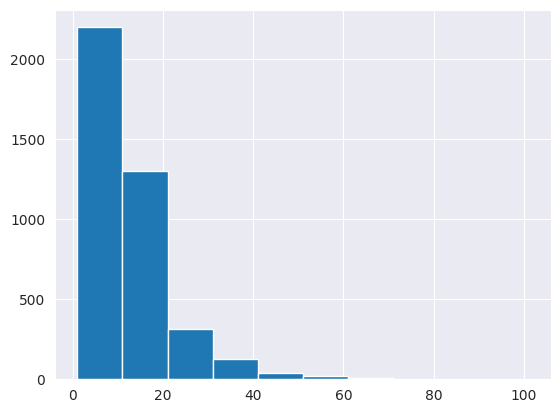

In [26]:
plt.hist(num_sentences)

In [27]:
preprocessed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in preprocessed_dataset]

positive_processed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in positive_processed_dataset]
negative_processed_dataset_documents = [" ".join(doc_sentences) for doc_sentences in negative_processed_dataset]


In [28]:
d1 = positive_processed_dataset_documents[0]
doc1 = nlp(d1)
doc1

every great once in a while, you stumble upon a movie that exceeds even your wildest expectations. given the imdb rating of 4.0, I was not really expecting much with the Brotherhood of Satan. I hoped that at a minimum it might be cheesy fun like the Devil's rain or any of the other early 70s similarly themed satanic horror films. I could not have been more wrong. what I got instead was an ambitious and intelligent film with a cast I really enjoyed. speaking in broad terms to avoid giving anything away, the film's style and structure are much more experimental than the straightforward storytelling so prominent in the early 70s. the Brotherhood of Satan does not beat you over the head with plot points and explanations. a lot is left to the viewer to fill in the blanks. as a viewer, you know something is amiss, but for the longest period you are just not sure what it is. the unknown helps make for a far creepier atmosphere than most similar films. the ending is effective with its surreal 

# New Version

In [49]:
import spacy
import torch
import networkx as nx
import numpy as np
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot

# --- Setup Logging ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# --- Constants and Configuration ---
COMMON_DEP_LABELS = [
    "nsubj", "obj", "iobj", "csubj", "ccomp", "xcomp", "obl", "amod", "advmod",
    "det", "case", "mark", "nmod", "acl", "conj", "cc", "punct", "root", "dep"
]


def get_positional_encoding(max_len: int, d_model: int) -> torch.Tensor:
    """Generates sinusoidal positional encodings."""
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    if d_model % 2 != 0:
        pe[:, 1::2] = torch.cos(position * div_term)[:, :pe[:, 1::2].shape[1]]
    else:
        pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class DocumentGraphBuilder:
    """
    A class to build multi-level, heterogeneous graphs from textual documents.
    This version implements our final hybrid architecture design:
    - Static, pre-computed features for all intra-layer edges.
    - No pre-computed weights for hierarchical (belongs) edges.
    """

    def __init__(self,
                 spacy_model: str = 'en_core_web_lg',
                 embedding_model: str = 'sentence-transformers/all-MiniLM-L6-v2',
                 similarity_threshold: float = 0.9):
        logging.info("Initializing DocumentGraphBuilder...")
        self.nlp = spacy.load(spacy_model)
        self.tokenizer = AutoTokenizer.from_pretrained(embedding_model)
        self.model = AutoModel.from_pretrained(embedding_model)
        self.similarity_threshold = similarity_threshold
        self.dep_label_map = {label: i for i, label in enumerate(COMMON_DEP_LABELS)}
        self.used_deps = {i: 0 for i, label in enumerate(COMMON_DEP_LABELS)}
        self.embedding_dim = self.model.config.hidden_size
        logging.info(f"Models and configuration loaded successfully. Embedding dim: {self.embedding_dim}")

    def _get_batch_embedding(self, texts: list[str]) -> torch.Tensor:
        """Generates embeddings for a batch of texts."""
        inputs = self.tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            outputs = self.model(**inputs)
        return outputs.last_hidden_state.mean(dim=1)

    def process_documents(self, documents: list[str]) -> tuple[list[nx.MultiDiGraph], list[HeteroData]]:
        """Processes a list of documents and returns their graph representations."""
        nx_graphs = []
        hetero_graphs = []
        for i, doc_text in enumerate(documents):
            logging.info(f"--- Processing Document {i + 1}/{len(documents)} ---")
            nx_graph, hetero_graph = self.build_graphs_for_document(doc_text, doc_id=i)
            nx_graphs.append(nx_graph)
            hetero_graphs.append(hetero_graph)
        return nx_graphs, hetero_graphs

    def build_graphs_for_document(self, doc_text: str, doc_id: int) -> tuple[nx.MultiDiGraph, HeteroData]:
        """Constructs both graph representations for a single document."""
        spacy_doc = self.nlp(doc_text)
        sentences = list(spacy_doc.sents)
        nx_graph = nx.MultiDiGraph(doc_id=doc_id, text=doc_text)
        doc_node_id = f"doc_{doc_id}"

        content_words = [tok.text for tok in spacy_doc if not tok.is_stop and not tok.is_punct]
        unique_content_words = sorted(list(set(content_words)))
        word_embeddings_map = {}
        if unique_content_words:
            word_embeddings_map = {word: emb for word, emb in
                                   zip(unique_content_words, self._get_batch_embedding(unique_content_words))}

        max_sent_len = max((len(list(s)) for s in sentences), default=0)
        positional_encodings = get_positional_encoding(max_sent_len, self.embedding_dim)

        lemma_to_nodes = {}
        processed_sentences = []

        for sent_idx, sent in enumerate(sentences):
            word_nodes_in_sent = []
            contextual_embs_for_sent = []

            for token in sent:
                word_node_id = f"word_{doc_id}_{token.i}"
                contextual_emb = torch.zeros(self.embedding_dim) # Default for stop/punct

                if token.is_stop or token.is_punct:
                    final_emb = torch.zeros(1, self.embedding_dim)
                else:
                    contextual_emb = word_embeddings_map.get(token.text, torch.zeros(self.embedding_dim))
                    pos_in_sent = token.i - sent.start
                    pos_emb = positional_encodings[pos_in_sent]
                    final_emb = (contextual_emb + pos_emb).unsqueeze(0)
                    contextual_embs_for_sent.append(contextual_emb)
                    if token.lemma_ not in lemma_to_nodes:
                        lemma_to_nodes[token.lemma_] = []
                    lemma_to_nodes[token.lemma_].append(word_node_id)

                # --- CHANGE: Store the initial contextual embedding for later use ('same_lemma' edges)
                nx_graph.add_node(word_node_id, type='word', text=token.text, x=final_emb, contextual_x=contextual_emb.unsqueeze(0))
                word_nodes_in_sent.append(word_node_id)

            if not contextual_embs_for_sent: continue

            # --- CHANGE: Simplified sentence embedding to an unweighted average. Attention is now learned by the GNN.
            final_sent_emb = torch.mean(torch.stack(contextual_embs_for_sent), dim=0).unsqueeze(0)
            sent_node_id = f"sent_{doc_id}_{sent_idx}"
            # This is the corrected line
            nx_graph.add_node(sent_node_id, type='sentence', text=sent.text, x=final_sent_emb, sentence_index=sent_idx)

            # --- CHANGE: Hierarchical 'belongs' edges now have no pre-computed weight.
            for wnid in word_nodes_in_sent:
                nx_graph.add_edge(wnid, sent_node_id, type='belongs')
            processed_sentences.append({'id': sent_node_id, 'embedding': final_sent_emb})

        if not processed_sentences:
            logging.warning(f"Document {doc_id} resulted in no processable sentences.")
            nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}", x=torch.zeros((1, self.embedding_dim)))
            return nx_graph, self.to_hetero_data(nx_graph)

        # --- CHANGE: Simplified document embedding. Sophisticated aggregation is deferred to the GNN.
        final_sentence_embeddings = torch.cat([s['embedding'] for s in processed_sentences])
        final_doc_embedding = torch.mean(final_sentence_embeddings, dim=0, keepdim=True)
        nx_graph.add_node(doc_node_id, type='document', text=f"DOC_{doc_id}", x=final_doc_embedding)

        # --- CHANGE: Hierarchical 'belongs' edges have no pre-computed weight.
        for sent_data in processed_sentences:
            nx_graph.add_edge(sent_data['id'], doc_node_id, type='belongs')

        # --- CHANGE: Add static features to all intra-layer edges ---
        for lemma, nodes in lemma_to_nodes.items():
            if len(nodes) > 1:
                for i in range(len(nodes)):
                    for j in range(i + 1, len(nodes)):
                        u_context = nx_graph.nodes[nodes[i]]['contextual_x']
                        v_context = nx_graph.nodes[nodes[j]]['contextual_x']
                        sim = cosine_similarity(u_context, v_context).item()
                        feature = torch.tensor([sim])
                        nx_graph.add_edge(nodes[i], nodes[j], type='same_lemma', feature=feature)
                        nx_graph.add_edge(nodes[j], nodes[i], type='same_lemma', feature=feature)

        for token in spacy_doc:
            u_id = f"word_{doc_id}_{token.i}"
            if token.i + 1 < len(spacy_doc) and spacy_doc[token.i + 1].sent == token.sent:
                v_id = f"word_{doc_id}_{token.i + 1}"
                nx_graph.add_edge(u_id, v_id, type='seq', feature=torch.tensor([1.0]))
            if token.head != token and nx_graph.has_node(f"word_{doc_id}_{token.head.i}"):
                v_id = f"word_{doc_id}_{token.head.i}"
                dep_idx = self.dep_label_map.get(token.dep_, self.dep_label_map['dep'])
                dep_feature = one_hot(torch.tensor(dep_idx), num_classes=len(self.dep_label_map)).float()
                nx_graph.add_edge(u_id, v_id, type='dep', feature=dep_feature)
                dep_idx = self.dep_label_map.get(token.dep_, self.dep_label_map['dep'])
                self.used_deps[dep_idx] += 1

        sentence_node_ids = [s['id'] for s in processed_sentences]
        for i in range(len(sentence_node_ids)):
            if i + 1 < len(sentence_node_ids):
                nx_graph.add_edge(sentence_node_ids[i], sentence_node_ids[i + 1], type='seq', feature=torch.tensor([1.0]))
            for j in range(i + 1, len(sentence_node_ids)):
                sim = cosine_similarity(nx_graph.nodes[sentence_node_ids[i]]['x'], nx_graph.nodes[sentence_node_ids[j]]['x']).item()
                if sim > self.similarity_threshold:
                    nx_graph.add_edge(sentence_node_ids[i], sentence_node_ids[j], type='sim', feature=torch.tensor([sim]))

        logging.info(f"Constructed NetworkX graph: {nx_graph.number_of_nodes()} nodes, {nx_graph.number_of_edges()} edges.")
        hetero_data = self.to_hetero_data(nx_graph)
        logging.info(f"Converted to HeteroData graph: \n{hetero_data}")
        return nx_graph, hetero_data

    def to_hetero_data(self, nx_graph: nx.MultiDiGraph) -> HeteroData:
        # This function is generic and should handle the new 'feature' attributes correctly
        data = HeteroData()
        node_types = {d['type'] for _, d in nx_graph.nodes(data=True) if 'type' in d}
        node_mappings = {
            ntype: {n: i for i, (n, d) in enumerate(nx_graph.nodes(data=True)) if d.get('type') == ntype}
            for ntype in node_types
        }

        for ntype, mapping in node_mappings.items():
            nodes_of_type = list(mapping.keys())
            if not nodes_of_type: continue

            # Gather primary 'x' features
            if 'x' in nx_graph.nodes[nodes_of_type[0]]:
                data[ntype].x = torch.cat([nx_graph.nodes[n]['x'] for n in nodes_of_type], dim=0)

            # Gather other attributes like text, but avoid features we don't want on the final graph
            other_attrs = {k for k in nx_graph.nodes[nodes_of_type[0]].keys() if k not in ['type', 'x', 'contextual_x']}
            for attr in other_attrs:
                values = [nx_graph.nodes[n][attr] for n in nodes_of_type]
                data[ntype][attr] = values

        for u, v, attrs in nx_graph.edges(data=True):
            src_type, dst_type = nx_graph.nodes[u].get('type'), nx_graph.nodes[v].get('type')
            if not src_type or not dst_type: continue

            edge_type = attrs['type']
            edge_tuple = (src_type, edge_type, dst_type)
            if u not in node_mappings[src_type] or v not in node_mappings[dst_type]: continue

            src_idx, dst_idx = node_mappings[src_type][u], node_mappings[dst_type][v]

            if 'edge_index' not in data[edge_tuple]:
                data[edge_tuple].edge_index = torch.empty((2, 0), dtype=torch.long)

            edge_index = torch.tensor([[src_idx], [dst_idx]], dtype=torch.long)
            data[edge_tuple].edge_index = torch.cat([data[edge_tuple].edge_index, edge_index], dim=1)

            # This loop now correctly captures the 'feature' attribute for intra-layer edges
            for attr_key, attr_val in attrs.items():
                if attr_key == 'type': continue
                if attr_key not in data[edge_tuple]: data[edge_tuple][attr_key] = []
                data[edge_tuple][attr_key].append(attr_val)

        for store in data.edge_stores:
            for key, value in store.items():
                if key != 'edge_index' and isinstance(value, list) and value:
                    try:
                        if isinstance(value[0], torch.Tensor):
                           # Use stack for features that are vectors/tensors themselves
                           store[key] = torch.stack(value, dim=0).squeeze(1) if value[0].numel() > 1 else torch.tensor(value)
                        else:
                           store[key] = torch.tensor(value)
                    except (TypeError, ValueError, RuntimeError) as e:
                        logging.warning(f"Could not convert edge attribute '{key}' to tensor: {e}")
                        pass
        return data

In [68]:
import spacy
import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle  # For drawing the grouping boxes
from pyvis.network import Network  # Import the new library


# --- Utility and Analysis Functions ---

def visualize_explanatory_graph(nx_graph: nx.MultiDiGraph):
    """
    Draws a high-quality, explanatory graph.
    UPDATED: Visualizes static edge features instead of pre-computed attention.
    """
    fig, ax = plt.subplots(figsize=(70, 30))
    pos = {}

    # --- 1. Define Color and Style Maps (No Change) ---
    node_color_map = {'document': '#d62828', 'sentence': '#003049', 'word': '#f77f00'}
    edge_color_map = {
        'belongs': '#2a9d8f', 'seq': '#e76f51', 'dep': '#8d99ae',
        'same_lemma': '#6a4c93', 'sim': '#118ab2'
    }

    # --- 2-3. Positioning Logic (No Change) ---
    # (The existing logic for node positioning remains effective)
    nodes_by_type = {'document': [], 'sentence': [], 'word': []}
    sent_to_words = {}
    for node, data in nx_graph.nodes(data=True):
        nodes_by_type[data['type']].append(node)
        if data['type'] == 'sentence':
            sent_to_words[node] = []
    for u, v, data in nx_graph.edges(data=True):
        if data.get('type') == 'belongs' and nx_graph.nodes[u]['type'] == 'word':
            sent_to_words[v].append(u)
    y_coords = {'document': 1.0, 'sentence': 0.0, 'word': -1.0}
    pos[nodes_by_type['document'][0]] = (0.5, y_coords['document'])
    sorted_sents = sorted(nodes_by_type['sentence'], key=lambda n: nx_graph.nodes[n]['sentence_index'])
    num_sentences = len(sorted_sents)
    total_plot_width = 0.9
    left_margin = (1 - total_plot_width) / 2
    if num_sentences > 1:
        group_space_ratio = 0.9
        total_group_width = total_plot_width * group_space_ratio
        total_gap_width = total_plot_width * (1 - group_space_ratio)
        single_group_width = total_group_width / num_sentences
        single_gap_width = total_gap_width / (num_sentences - 1)
    else:
        single_group_width = total_plot_width
        single_gap_width = 0
    current_x = left_margin
    for sent_node in sorted_sents:
        x_start = current_x
        x_end = x_start + single_group_width
        sent_x = (x_start + x_end) / 2
        pos[sent_node] = (sent_x, y_coords['sentence'])
        words_in_sent = sorted(sent_to_words[sent_node], key=lambda n: nx_graph.nodes[n]['position_in_doc'])
        num_words = len(words_in_sent)
        padding = 0.1 * single_group_width
        word_x_coords = np.linspace(x_start + padding, x_end - padding, num_words) if num_words > 1 else [sent_x]
        y_base = y_coords['word']
        y_stagger_offset = 0.2
        for j, word_node in enumerate(words_in_sent):
            y_pos = y_base if j % 2 == 0 else y_base - y_stagger_offset
            pos[word_node] = (word_x_coords[j], y_pos)
        rect = Rectangle((x_start, y_coords['word'] - y_stagger_offset - 0.1),
                         width=single_group_width, height=0.4 + y_stagger_offset,
                         facecolor='#f8f9fa', edgecolor='#ced4da', linestyle='--', alpha=0.6, zorder=0)
        ax.add_patch(rect)
        current_x = x_end + single_gap_width

    # --- 4. Labels and Sizes (No Change) ---
    labels, node_colors, node_sizes = {}, [], []
    for node, data in nx_graph.nodes(data=True):
        node_colors.append(node_color_map[data['type']])
        text_label = data['text']
        if data['type'] == 'word':
            labels[node] = text_label
            node_sizes.append(1000 + len(text_label) * 250)
        elif data['type'] == 'sentence':
            labels[node] = f"SENT_{data['sentence_index']}"
            node_sizes.append(5000)
        else:
            labels[node] = text_label
            node_sizes.append(6000)

    # --- 5. Draw Graph Elements (UPDATED LOGIC) ---
    nx.draw_networkx_nodes(nx_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=1.0, ax=ax)
    nx.draw_networkx_labels(nx_graph, pos, labels=labels, font_size=9, font_weight='bold', font_color='white', ax=ax)

    for u, v, data in nx_graph.edges(data=True):
        edge_type = data['type']
        edge_color = edge_color_map.get(edge_type, '#b7b7a4')

        # --- CHANGE: Updated edge style logic ---
        # 'belongs' edges are now fixed style, as their weight is learned.
        if edge_type == 'belongs':
            alpha = 0.9
            lw = 2.5
        # For other edges, use the static feature to determine style.
        else:
            alpha = 0.7
            # Use the scalar feature for line width if it exists
            feature_val = data.get('feature', torch.tensor([1.0])).item()
            lw = 1.0 + (feature_val * 3.0) # Scale feature (0-1) to a visible width

        rad = 0.15
        if hash(u) > hash(v): rad = -rad
        if nx_graph.nodes[u]['type'] == nx_graph.nodes[v]['type']: rad = 0.2

        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="->", color=edge_color, alpha=alpha, lw=lw,
                                    shrinkA=35, shrinkB=35, patchA=None, patchB=None,
                                    connectionstyle=f"arc3,rad={rad}"))

    # --- 6. Create Legend (UPDATED LOGIC) ---
    legend_handles = []
    for node_type, color in node_color_map.items():
        legend_handles.append(Line2D([0], [0], marker='o', color='w', label=f'Node: {node_type.capitalize()}',
                                     markersize=15, markerfacecolor=color))
    for edge_type, color in edge_color_map.items():
        # --- CHANGE: Removed mention of attention ---
        label = f'Edge: {edge_type.capitalize()}'
        if edge_type in ['sim', 'same_lemma']: label += ' (Width = Feature)'
        legend_handles.append(Line2D([0], [0], color=color, lw=4, label=label))

    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
              fancybox=True, shadow=True, ncol=4, fontsize=14)
    ax.set_title(f"Explanatory Graph Structure (Doc ID: {nx_graph.graph.get('doc_id', 'N/A')})", size=28, pad=20)
    plt.subplots_adjust(bottom=0.1, top=0.95)
    plt.axis('off')
    plt.show()

import spacy
import torch
import networkx as nx
import numpy as np
import logging
from torch_geometric.data import HeteroData
from transformers import AutoTokenizer, AutoModel
from torch.nn.functional import cosine_similarity, softmax, one_hot
from pyvis.network import Network


def visualize_interactive_graph(nx_graph: nx.MultiDiGraph, output_filename: str = "interactive_graph.html"):
    """
    Creates a beautiful, interactive, physics-based graph visualization.

    UPDATED:
    - Adds an interactive filter to show/hide both nodes and edges by type.
    - Adds a neighborhood highlighting feature on click/hover.
    """
    logging.info(f"Creating interactive graph, saving to {output_filename}...")
    net = Network(height="800px", width="100%", bgcolor="#222222", font_color="white", notebook=True,
                  cdn_resources='in_line')

    node_color_map = {'document': '#d62828', 'sentence': '#003049', 'word': '#f77f00'}
    edge_color_map = {
        'belongs': '#2a9d8f', 'seq': '#e76f51', 'dep': '#8d99ae',
        'same_lemma': '#6a4c93', 'sim': '#118ab2'
    }

    # --- 3. Add Nodes to the Pyvis Network (UPDATED) ---
    for node, data in nx_graph.nodes(data=True):
        node_type = data['type']
        label = data['text']

        # --- CHANGE: Assign the node_type to the 'group' for filtering ---
        group = node_type

        title = f"Type: {node_type.capitalize()}\nText: {label}"
        if node_type == 'sentence':
            # This information is from the context of building a graph based on a document
            label = f"SENT_{data['sentence_index']}"
        size = 30 if node_type == 'document' else 20 if node_type == 'sentence' else 10 + len(str(label))

        net.add_node(
            node,
            label=str(label),
            title=title,
            color=node_color_map.get(node_type, 'grey'),
            size=size,
            group=group
        )

    # --- 4. Add Edges to the Pyvis Network (No Change from previous version) ---
    for u, v, data in nx_graph.edges(data=True):
        edge_type = data['type']
        group = edge_type
        if edge_type == 'belongs':
            width = 4
            title = "Type: Belongs (Learned Weight)"
        else:
            feature_val = data.get('feature', torch.tensor([1.0]))
            if edge_type == 'dep':
                width = 1
                title = "Type: Dependency"
            else:
                scalar_feature = feature_val.item()
                width = 1 + (scalar_feature * 4.0)
                title = f"Type: {edge_type.capitalize()}\nFeature: {scalar_feature:.4f}"
        net.add_edge(u, v, title=title, color=edge_color_map.get(edge_type, 'grey'), width=width, group=group)

    # --- 5. Configure Physics and Interaction Options (No Change from previous version) ---
    options = """
    var options = {
      "configure": {
        "enabled": true,
        "filter": "nodes,edges"
      },
      "interaction": {
        "hover": true,
        "hoverConnectedEdges": true,
        "keyboard": { "enabled": true },
        "navigationButtons": true,
        "tooltipDelay": 300,
        "hideEdgesOnDrag": true,
        "highlightNearest": {
          "enabled": true,
          "degree": 1,
          "hover": true
        }
      },
      "physics": {
        "enabled": true,
        "solver": "forceAtlas2Based",
        "forceAtlas2Based": {
          "gravitationalConstant": -50,
          "centralGravity": 0.01,
          "springLength": 100,
          "springConstant": 0.08
        }
      }
    }
    """
    net.set_options(options)

    # --- 6. Generate and Save the Graph ---
    try:
        net.save_graph(output_filename)
        logging.info("Successfully saved interactive graph.")
    except Exception as e:
        logging.error(f"Could not save interactive graph: {e}")

def extract_explanations(nx_graph: nx.MultiDiGraph) -> dict:
    """
    DEPRECATED: This function is incompatible with the new graph structure
    as attention scores are no longer pre-computed.

    The new approach for extracting explanations must be performed *after*
    GNN processing and will require access to the trained model to inspect
    the learned hierarchical attention weights.

    A future function signature would look like:
    `extract_learned_explanations(graph_data, trained_gnn_model)`
    """
    logging.warning(
        "DEPRECATION WARNING: extract_explanations() is being called but is incompatible "
        "with the new graph design. It will return an empty dictionary. "
        "Explanations must now be extracted from the trained GNN model itself."
    )
    # Return an empty structure to avoid breaking downstream code.
    return {"top_sentences": [], "top_words_per_sentence": {}}


## Main Execution Block

In [69]:
sample_documents = positive_processed_dataset_documents[:5]

In [70]:
graph_builder = DocumentGraphBuilder()
nx_graphs, hetero_graphs = graph_builder.process_documents(sample_documents)
print(COMMON_DEP_LABELS)
print(graph_builder.used_deps)

dependency_counts = {
    COMMON_DEP_LABELS[index]: count
    for index, count in graph_builder.used_deps.items()
}

print("--- Created with Dictionary Comprehension ---")
print(dependency_counts)
print("-" * 40)

2025-06-11 20:30:27,295 - INFO - Initializing DocumentGraphBuilder...
2025-06-11 20:30:31,638 - INFO - Models and configuration loaded successfully. Embedding dim: 384
2025-06-11 20:30:31,658 - INFO - --- Processing Document 1/5 ---
2025-06-11 20:30:32,007 - INFO - Constructed NetworkX graph: 509 nodes, 1677 edges.
2025-06-11 20:30:32,099 - INFO - Converted to HeteroData graph: 
HeteroData(
  document={
    x=[1, 384],
    text=[1],
  },
  word={
    x=[485, 384],
    text=[485],
  },
  sentence={
    x=[23, 384],
    text=[23],
    sentence_index=[23],
  },
  (word, belongs, sentence)={ edge_index=[2, 482] },
  (word, seq, word)={
    edge_index=[2, 461],
    feature=[461],
  },
  (word, dep, word)={
    edge_index=[2, 461],
    feature=[461, 19],
  },
  (sentence, belongs, document)={ edge_index=[2, 23] },
  (sentence, seq, sentence)={
    edge_index=[2, 22],
    feature=[22],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 74],
    feature=[74],
  },
  (word, same_lemma, word)

['nsubj', 'obj', 'iobj', 'csubj', 'ccomp', 'xcomp', 'obl', 'amod', 'advmod', 'det', 'case', 'mark', 'nmod', 'acl', 'conj', 'cc', 'punct', 'root', 'dep']
{0: 107, 1: 0, 2: 0, 3: 1, 4: 22, 5: 17, 6: 0, 7: 63, 8: 82, 9: 110, 10: 6, 11: 20, 12: 1, 13: 6, 14: 49, 15: 50, 16: 118, 17: 0, 18: 523}
--- Created with Dictionary Comprehension ---
{'nsubj': 107, 'obj': 0, 'iobj': 0, 'csubj': 1, 'ccomp': 22, 'xcomp': 17, 'obl': 0, 'amod': 63, 'advmod': 82, 'det': 110, 'case': 6, 'mark': 20, 'nmod': 1, 'acl': 6, 'conj': 49, 'cc': 50, 'punct': 118, 'root': 0, 'dep': 523}
----------------------------------------


In [71]:
# --- Analysis and Visualization of Document 1 ---
print("\n\n" + "=" * 50)
print(f"--- Analysis of Document 1: \n\"{sample_documents[0]}\"\n ---")
print("=" * 50)

doc1_nx = nx_graphs[0]

# # Extract and show explanations
# explanations = extract_explanations(doc1_nx)
# print("\n[INFO] Explanations (via Semantic Attention):")
# print("Top Sentences:")
# for text, score in explanations['top_sentences']:
#     print(f"  - Score: {score:.4f}, Text: '{text}'")

# Generate and show the new hierarchical visualization
# Generate and show the new explanatory visualization
# print("\n[INFO] Generating explanatory graph visualization for Document 1...")
# visualize_explanatory_graph(doc1_nx)




--- Analysis of Document 1: 
"every great once in a while, you stumble upon a movie that exceeds even your wildest expectations. given the imdb rating of 4.0, I was not really expecting much with the Brotherhood of Satan. I hoped that at a minimum it might be cheesy fun like the Devil's rain or any of the other early 70s similarly themed satanic horror films. I could not have been more wrong. what I got instead was an ambitious and intelligent film with a cast I really enjoyed. speaking in broad terms to avoid giving anything away, the film's style and structure are much more experimental than the straightforward storytelling so prominent in the early 70s. the Brotherhood of Satan does not beat you over the head with plot points and explanations. a lot is left to the viewer to fill in the blanks. as a viewer, you know something is amiss, but for the longest period you are just not sure what it is. the unknown helps make for a far creepier atmosphere than most similar films. the endin

In [72]:
 # --- Call the NEW interactive visualization function ---
# This will create an HTML file in your directory.
# If you are in a Jupyter Notebook, it will also display the graph inline.
visualize_interactive_graph(doc1_nx, output_filename="final_interactive_document_graph.html")
print("\nInteractive graph has been generated and saved as 'final_interactive_document_graph.html'.")
print("Open this file in a web browser to zoom, drag nodes, and explore the graph.")

2025-06-11 20:30:32,866 - INFO - Creating interactive graph, saving to final_interactive_document_graph.html...
2025-06-11 20:30:33,334 - INFO - Successfully saved interactive graph.



Interactive graph has been generated and saved as 'final_interactive_document_graph.html'.
Open this file in a web browser to zoom, drag nodes, and explore the graph.


# GNN Modelling


In [73]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, GATv2Conv, HeteroConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume 'DocumentGraphBuilder' from the previous step is in a file named 'graph_builder.py'
# from graph_builder import DocumentGraphBuilder


In [74]:
import itertools


# --- 1. Data Simulation and Preparation ---
def prepare_dataset():
    """
    Simulates a raw dataset and processes it using DocumentGraphBuilder.
    """
    # For demonstration, we'll create dummy documents for N classes.
    # In a real scenario, you would load your actual text files here.
    documents_by_class = {
        "positive": positive_processed_dataset_documents,
        "negative": negative_processed_dataset_documents
    }

    class_names = list(documents_by_class.keys())

    graph_builder = DocumentGraphBuilder()
    graph_list = []
    labels_list = []

    for class_idx, (class_name, docs) in enumerate(documents_by_class.items()):
        print(f"\n--- Processing Class: {class_name} ---")
        _, hetero_graphs = graph_builder.process_documents(docs)
        graph_list.extend(hetero_graphs)
        labels_list.extend([class_idx] * len(hetero_graphs))

    return graph_list, labels_list, class_names

In [75]:

# --- 2. GNN Model Definition ---

class HeteroGNN(torch.nn.Module):
    """
    A Heterogeneous Graph Neural Network for graph-level classification.
    """

    def __init__(self, hidden_channels, out_channels, num_layers=2):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv({
                ('word', 'seq', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'dep', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'seq', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'same_lemma', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'sim', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'belongs', 'sentence'): GATv2Conv((-1, -1), hidden_channels, add_self_loops=False),
                ('sentence', 'belongs', 'document'): GATv2Conv((-1, -1), hidden_channels, add_self_loops=False),
                ('sentence', 'rev_belongs', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('document', 'rev_belongs', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'rev_dep', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('word', 'rev_seq', 'word'): SAGEConv(-1, hidden_channels, aggr='mean'),
                ('sentence', 'rev_seq', 'sentence'): SAGEConv(-1, hidden_channels, aggr='mean'),
            }, aggr='sum')
            self.convs.append(conv)

        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, data, return_attention_for_explainability=False):
        x_dict, edge_index_dict = data.x_dict, data.edge_index_dict
        attention_storage = {}

        for i, conv in enumerate(self.convs):
            # For explainability, we need to get attention weights from GAT layers
            if return_attention_for_explainability and i == 0:
                # The GATv2Conv layer for word->sentence edges
                gat_layer = conv.convs['word__belongs__sentence']

                # Perform the convolution and request attention weights
                x_word, (edge_index, alpha) = gat_layer(
                    (x_dict['word'], x_dict['sentence']),
                    edge_index_dict[('word', 'belongs', 'sentence')],
                    return_attention_weights=True
                )
                attention_storage['word_to_sentence'] = alpha

                # To get a valid forward pass, we need to manually update the output dict
                # This is a bit of a hack for explainability. A more robust solution might
                # involve custom layers, but this works for demonstration.
                out_dict = conv(x_dict, edge_index_dict)
                out_dict['sentence'] = x_word  # Overwrite with the result from our GAT call
                x_dict = out_dict
            else:
                x_dict = conv(x_dict, edge_index_dict)

            x_dict = {key: x.relu() for key, x in x_dict.items()}

        doc_embedding = x_dict['document']
        out = self.lin(doc_embedding)

        if return_attention_for_explainability:
            return out, attention_storage
        return out

In [76]:

# --- 3. Training and Evaluation Loop ---

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        data = T.ToUndirected(merge=False)(data)
        out = model(data)
        loss = criterion(out, data['document'].y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def test(model, loader):
    model.eval()
    total_correct = 0
    all_preds, all_labels = [], []
    for data in loader:
        data = T.ToUndirected(merge=False)(data)
        out = model(data)
        pred = out.argmax(dim=-1)
        total_correct += int((pred == data['document'].y).sum())
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data['document'].y.cpu().numpy())
    accuracy = total_correct / len(loader.dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted',
                                                               zero_division=0)
    return accuracy, precision, recall, f1, all_labels, all_preds


In [ ]:

# --- 4. Main Execution ---
if __name__ == '__main__':

    # 1. Prepare Data
    graphs, labels, class_names = prepare_dataset()
    for i, graph in enumerate(graphs):
        graph['document'].y = torch.tensor([labels[i]])

    # 2. Stratified Split
    train_graphs, test_graphs = train_test_split(graphs, test_size=0.3, random_state=42, stratify=labels)
    val_graphs, test_graphs = train_test_split(test_graphs, test_size=0.5, random_state=42,
                                               stratify=[g['document'].y.item() for g in test_graphs])

    print(f"Dataset split: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

    # 3. Create DataLoaders
    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=16)
    test_loader = DataLoader(test_graphs, batch_size=16)

    # 4. Initialize Model and Training Components
    model = HeteroGNN(hidden_channels=64, out_channels=len(class_names), num_layers=2)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    criterion = torch.nn.CrossEntropyLoss()

    # 5. Training Loop
    best_val_f1 = 0
    for epoch in range(1, 51):
        loss = train(model, train_loader, optimizer, criterion)
        val_acc, val_p, val_r, val_f1, _, _ = test(model, val_loader)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model.pth')
        if epoch % 10 == 0:
            print(f'Epoch {epoch:02d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}')

    # 6. Final Evaluation
    print("\n--- Final Evaluation on Test Set ---")
    model.load_state_dict(torch.load('best_model.pth'))
    test_acc, test_p, test_r, test_f1, true_labels, pred_labels = test(model, test_loader)
    print(f'Test Accuracy:  {test_acc:.4f}')
    print(f'Test Precision: {test_p:.4f}')
    print(f'Test Recall:    {test_r:.4f}')
    print(f'Test F1-Score:  {test_f1:.4f}')

    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(pd.DataFrame(cm, index=class_names, columns=class_names), annot=True, cmap='Blues', fmt='g')
    plt.title('Confusion Matrix'), plt.ylabel('Actual'), plt.xlabel('Predicted')
    plt.show()

    # 7. Explainability
    print("\n--- Explainability: Analyzing Attention Scores ---")
    try:
        explain_graph = test_graphs[0]
        true_label_idx = explain_graph['document'].y.item()

        model.eval()
        with torch.no_grad():
            explain_data = T.ToUndirected(merge=False)(explain_graph)
            _, attentions = model(explain_data, return_attention_for_explainability=True)

        word_sent_attention = attentions['word_to_sentence']
        edge_index = explain_data['word', 'belongs', 'sentence'].edge_index
        word_nodes_text = [t for t in explain_graph['word'].text]  # Ensure text is a list
        sent_nodes_text = [t for t in explain_graph['sentence'].text]

        print(f"Analyzing attention for a document with true label: '{class_names[true_label_idx]}'")

        attention_data = []
        for i in range(edge_index.size(1)):
            word_idx, sent_idx = edge_index[0, i], edge_index[1, i]
            attention_data.append({
                'word': word_nodes_text[word_idx],
                'sentence': sent_nodes_text[sent_idx],
                'attention': word_sent_attention[i].item()
            })

        df = pd.DataFrame(attention_data)

        for sentence, group in df.groupby('sentence'):
            top_words = group.sort_values('attention', ascending=False).head(5)
            print(f"\nSentence: \"{sentence}\"")
            for _, row in top_words.iterrows():
                print(f"  - Word: '{row['word']}' | Learned Attention: {row['attention']:.4f}")

    except Exception as e:
        print(f"\nCould not generate full attention explanation due to an error: {e}")
        import traceback

        traceback.print_exc()

2025-06-11 20:30:33,643 - INFO - Initializing DocumentGraphBuilder...
2025-06-11 20:30:37,485 - INFO - Models and configuration loaded successfully. Embedding dim: 384
2025-06-11 20:30:37,489 - INFO - --- Processing Document 1/2000 ---



--- Processing Class: positive ---


2025-06-11 20:30:37,958 - INFO - Constructed NetworkX graph: 509 nodes, 1677 edges.
2025-06-11 20:30:38,047 - INFO - Converted to HeteroData graph: 
HeteroData(
  document={
    x=[1, 384],
    text=[1],
  },
  word={
    x=[485, 384],
    text=[485],
  },
  sentence={
    x=[23, 384],
    text=[23],
    sentence_index=[23],
  },
  (word, belongs, sentence)={ edge_index=[2, 482] },
  (word, seq, word)={
    edge_index=[2, 461],
    feature=[461],
  },
  (word, dep, word)={
    edge_index=[2, 461],
    feature=[461, 19],
  },
  (sentence, belongs, document)={ edge_index=[2, 23] },
  (sentence, seq, sentence)={
    edge_index=[2, 22],
    feature=[22],
  },
  (sentence, sim, sentence)={
    edge_index=[2, 74],
    feature=[74],
  },
  (word, same_lemma, word)={
    edge_index=[2, 154],
    feature=[154],
  }
)
2025-06-11 20:30:38,048 - INFO - --- Processing Document 2/2000 ---
2025-06-11 20:30:38,173 - INFO - Constructed NetworkX graph: 152 nodes, 452 edges.
2025-06-11 20:30:38,192 - INF